In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [3]:
N = 8
wd = 0.642570281124498
tlist = np.linspace(0, 50, 150)
dlist = np.linspace(0, 2, 21)
alist = np.linspace(0.1, 2, 20)

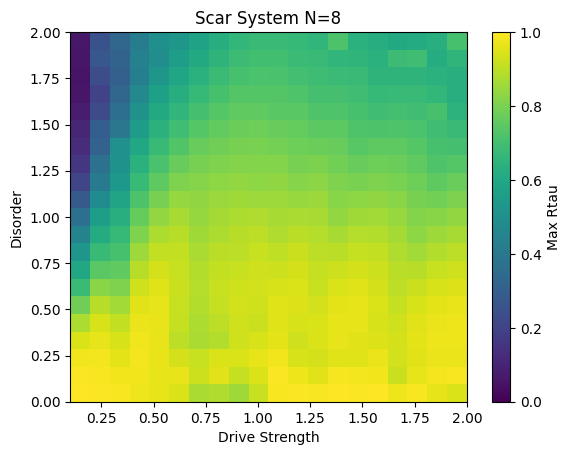

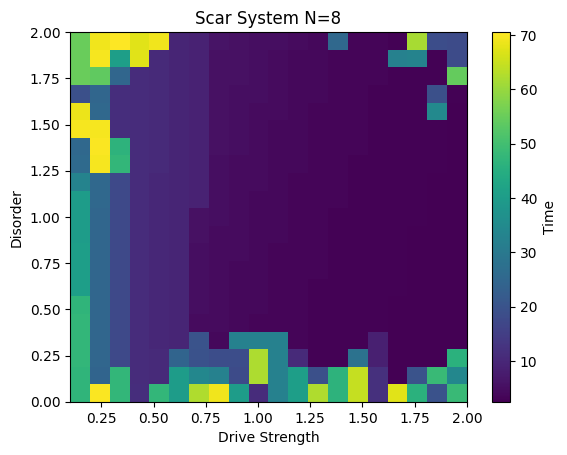

In [4]:
maxRtau = []
maxRtau_time = []

for d in dlist:
    temp = []
    temp_time = []
    for a in alist:
        H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, detuning=d, disorder=True)
        args = {"A": a, "omega": wd}
        H = qt.QobjEvo([H0, [H1, coeff]], args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])

        Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0])
        temp.append(np.max(Rtau))
        temp_time.append(np.argmax(Rtau) * 0.5)
    maxRtau.append(temp)
    maxRtau_time.append(temp_time)

plt.imshow(maxRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Max Rtau")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

plt.imshow(maxRtau_time,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Time")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

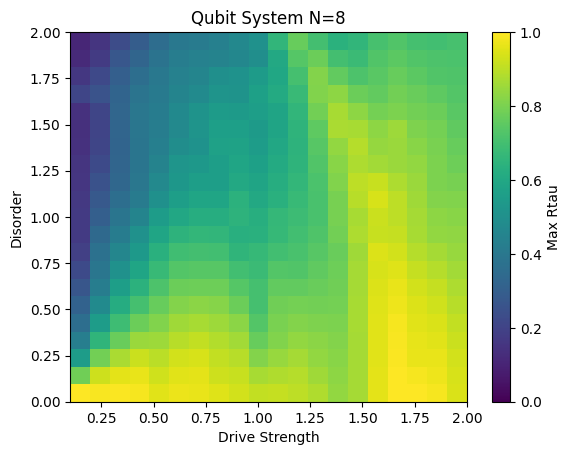

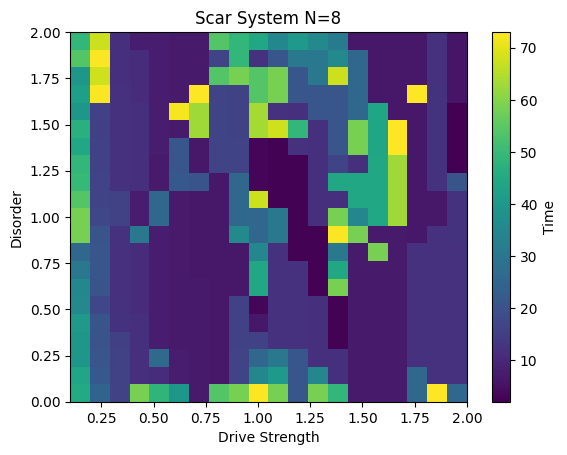

In [5]:
qN = 8
wm = 1.0
qmaxRtau = []
qmaxRtau_time = []

for d in dlist:
    temp = []
    temp_time = []
    for a in alist:
        qH0, qH1 = get_qubit_ham(N, wm=wm, disorder=True, detuning=d)
        qeigvals, qeigstates = qH0.eigenstates()
        qband = qeigvals[-1] - qeigvals[0]

        qargs = {"A": a, "omega": wm}
        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])

        Rtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
        temp.append(np.max(Rtau))
        temp_time.append(np.argmax(Rtau) * 0.5)
    qmaxRtau.append(temp)
    qmaxRtau_time.append(temp_time)

plt.imshow(qmaxRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Max Rtau")
plt.title(f"Qubit System N={qN}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

plt.imshow(qmaxRtau_time,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Time")
plt.title(f"Scar System N={qN}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()